In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import START_DATE, END_DATE, extent_to_rd, extent_to_ee, NDVI_START_DATE, NDVI_END_DATE
import numpy as np
import pastas as ps
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

hpd.util.get_color_logger("INFO")

# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)

<RootLogger root (INFO)>

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = extent_to_rd("gw") 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 3
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|██████████| 3/3 [00:10<00:00,  3.51s/it]


In [4]:
gw = oc.obs["GMW000000037950001"]
print(gw)

GroundwaterObs GMW000000037950001
-----metadata------
name : GMW000000037950001 
x : 91148.86201235745 
y : 436904.95065888227 
location : 128567-945 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -2.4 
screen_bottom : -4.4 
ground_level : -1.32 
tube_top : -1.4 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2016-01-13 00:00:00  -2.59   NaN  Gemeten   hand
2016-02-11 00:00:00  -2.55   NaN  Gemeten   hand
2016-03-15 00:00:00  -2.66   NaN  Gemeten   hand
2016-04-11 23:00:00  -2.62   NaN  Gemeten   hand
2016-05-10 23:00:00  -2.64   NaN  Gemeten   hand
...                    ...   ...      ...    ...
2026-03-29 00:20:00  -2.81   2.0           diver
2026-03-29 00:30:00  -2.81   2.0           diver
2026-03-29 00:40:00  -2.80   2.0           diver
2026-03-29 00:50:00  -2.80   2.0           diver
2026-03-29 01:00:00  -2.80   2.0           diver

[9329 rows x 4 columns]

Counts per origin:
 origin
diver_validated    1269
diver              1165
hand                  2
Name: value, dtype: int64
Primary origin chosen: diver_validated
Daily series points: 346


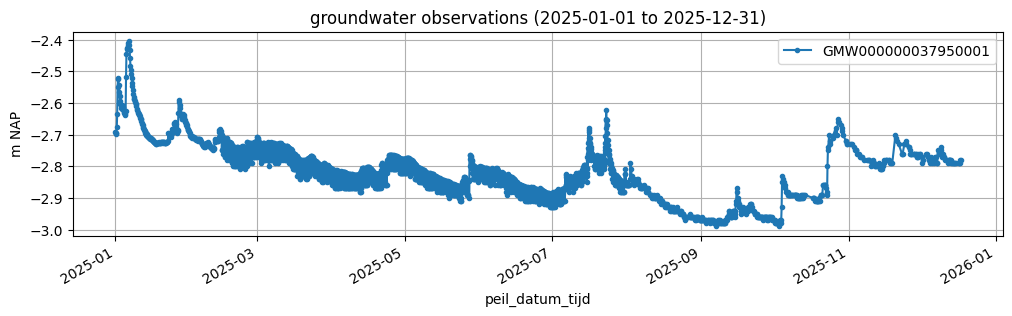

In [5]:
# Gebruik centrale tijdconfiguratie
tmin = START_DATE
tmax = END_DATE

def build_daily_gw_fill(
    gw_df: pd.DataFrame,
    tmin=None,
    tmax=None,
    primary_rule="most_obs",                 # "most_obs"
    fill_priority=("hand", "diver_validated", "diver"),
    within_day="last",                       # "last" or "median"
):
    df = gw_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.dropna(subset=["value", "origin"]).sort_index()

    # filter op periode
    if tmin is not None:
        df = df.loc[df.index >= pd.to_datetime(tmin)]
    if tmax is not None:
        df = df.loc[df.index <= pd.to_datetime(tmax)]

    # dagkolom
    df["date"] = df.index.floor("D")

    # helper: maak daily series voor 1 origin
    def daily_for_origin(origin):
        dfo = df[df["origin"] == origin].copy()
        if dfo.empty:
            return pd.Series(dtype="float64"), pd.Series(dtype="object")

        if within_day == "last":
            dfo = dfo.groupby("date").tail(1)
            s = dfo.set_index("date")["value"].sort_index()
        elif within_day == "median":
            s = dfo.groupby("date")["value"].median().sort_index()
        else:
            raise ValueError("within_day must be 'last' or 'median'")

        used = pd.Series(origin, index=s.index, name="origin_used")
        return s, used

    # 1) bepaal primary origin (meeste metingen)
    counts = df.groupby("origin")["value"].count().sort_values(ascending=False)
    if counts.empty:
        raise ValueError("Geen data in gw_df na filtering.")

    primary_origin = counts.index[0]
    primary_series, origin_used = daily_for_origin(primary_origin)

    # 2) aanvullen met andere origins
    combined = primary_series.copy()
    fill_list = [o for o in fill_priority if o != primary_origin]

    for o in fill_list:
        s_o, used_o = daily_for_origin(o)
        if s_o.empty:
            continue

        union_idx = combined.index.union(s_o.index)
        combined = combined.reindex(union_idx)
        origin_used = origin_used.reindex(union_idx)

        mask = combined.isna()
        combined.loc[mask] = s_o.reindex(union_idx).loc[mask]
        origin_used.loc[mask] = used_o.reindex(union_idx).loc[mask]

    combined.name = "gw_daily"

    return combined.sort_index(), origin_used.sort_index(), primary_origin, counts


# ---- gebruik ----
gw_daily, gw_origin_used, primary_origin, counts = build_daily_gw_fill(
    gw,
    tmin=tmin,
    tmax=tmax,
    fill_priority=("hand", "diver_validated", "diver"),
    within_day="last",
)

print("Counts per origin:\n", counts)
print("Primary origin chosen:", primary_origin)
print("Daily series points:", gw_daily.notna().sum())

# ---- ruwe groundwater plot ook op hetzelfde tijdvenster ----
gw_plot = gw.copy()
gw_plot.index = pd.to_datetime(gw_plot.index)
gw_plot = gw_plot.loc[(gw_plot.index >= tmin) & (gw_plot.index <= tmax)]

ax = gw_plot["value"].plot(
    figsize=(12, 3),
    marker=".",
    grid=True,
    label=getattr(gw, "name", "gw"),
    legend=True,
    ylabel="m NAP",
    title=f"groundwater observations ({tmin} to {tmax})",
)

INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (91148.86201235745, 436904.95065888227) and meteovariable RH
INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (91148.86201235745, 436904.95065888227) and meteovariable EV24
  return ax.plot(*args, **kwds)



<Axes: title={'center': 'meteo observations'}, ylabel='m/dag'>

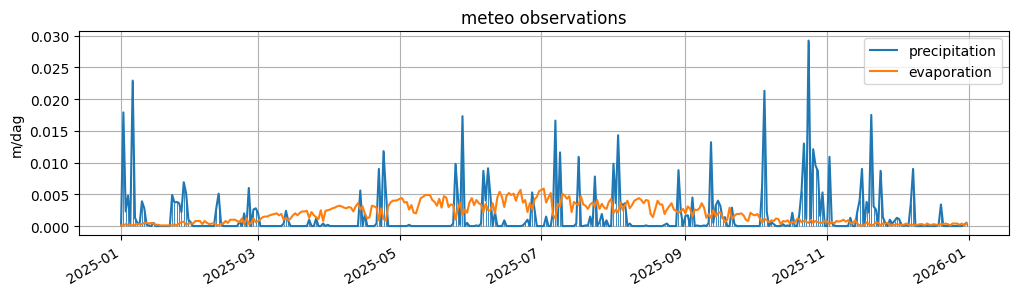

In [6]:
precipitation = hpd.PrecipitationObs.from_knmi(
    xy=(gw.x, gw.y),
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)
evaporation = hpd.EvaporationObs.from_knmi(
    xy=(gw.x, gw.y),
    meteo_var="EV24",
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)

# --- Plot as spikes (like rainfall graphs) ---
fig, ax = plt.subplots(figsize=(12, 3))

# precipitation as vertical lines
ax.vlines(
    precipitation.index,
    ymin=0,
    ymax=precipitation["RH"],
    linewidth=0.6,
    label="precipitation",
)

ax = precipitation["RH"].plot(label="precipitation", legend=True, figsize=(12, 3))
evaporation["EV24"].plot(
    ax=ax,
    label="evaporation",
    legend=True,
    grid=True,
    ylabel="m/dag",
    title="meteo observations",
)

Samples used: 346
Best lag = 3 days, correlation r = 0.333
No lag:   GW = 0.0063·R + -2.805   | r = 0.309 | R² = 0.095
With lag: GW = 0.0067·R(t-3) + -2.807   | r = 0.333 | R² = 0.111


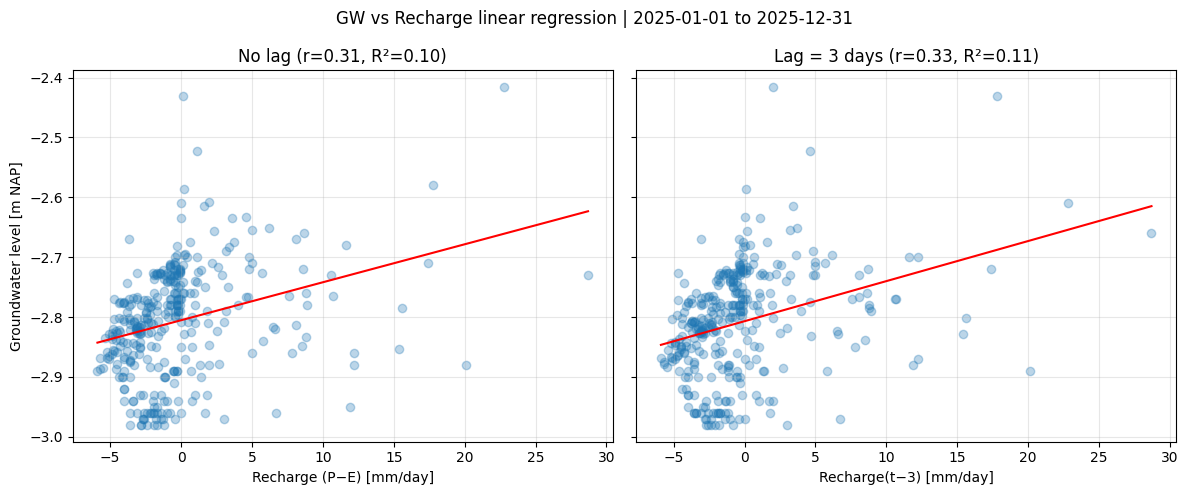

In [7]:
# -----------------------------
# USER SETTINGS
# -----------------------------
tmin = START_DATE
tmax = END_DATE
max_lag_days = 180

# -----------------------------
# 1) Rebuild df = GW + Recharge
# -----------------------------
gw = gw_daily.copy()
gw.name = "gw"

P = precipitation["RH"].resample("D").sum()
E = evaporation["EV24"].resample("D").sum()
recharge = (P - E) * 1000.0
recharge.name = "recharge"

df = pd.concat([gw, recharge], axis=1).dropna()
df = df.loc[df.index >= pd.to_datetime(tmin)]
if tmax is not None:
    df = df.loc[df.index <= pd.to_datetime(tmax)]

print("Samples used:", len(df))

# -----------------------------
# 2) Find best lag (0–max_lag_days)
# -----------------------------
lags = np.arange(0, max_lag_days + 1)
cors = np.array([df["gw"].corr(df["recharge"].shift(lag)) for lag in lags])

best_idx = np.nanargmax(np.abs(cors))
best_lag = int(lags[best_idx])
best_corr = float(cors[best_idx])

print(f"Best lag = {best_lag} days, correlation r = {best_corr:.3f}")

# -----------------------------
# 3) Regression WITHOUT lag
# -----------------------------
df0 = df.copy()
X0 = df0[["recharge"]].values
y0 = df0["gw"].values

m0 = LinearRegression().fit(X0, y0)
y0_hat = m0.predict(X0)

r2_0 = r2_score(y0, y0_hat)
r_0 = float(df0["gw"].corr(df0["recharge"]))

# -----------------------------
# 4) Regression WITH best lag
# -----------------------------
dfL = pd.DataFrame({
    "gw": df["gw"],
    "recharge": df["recharge"].shift(best_lag)
}).dropna()

XL = dfL[["recharge"]].values
yL = dfL["gw"].values

mL = LinearRegression().fit(XL, yL)
yL_hat = mL.predict(XL)

r2_L = r2_score(yL, yL_hat)
r_L = float(dfL["gw"].corr(dfL["recharge"]))

print(f"No lag:   GW = {m0.coef_[0]:.4f}·R + {m0.intercept_:.3f}   | r = {r_0:.3f} | R² = {r2_0:.3f}")
print(f"With lag: GW = {mL.coef_[0]:.4f}·R(t-{best_lag}) + {mL.intercept_:.3f}   | r = {r_L:.3f} | R² = {r2_L:.3f}")

# -----------------------------
# 5) Plot: scatter + regression lines
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# no lag
axes[0].scatter(df0["recharge"], df0["gw"], alpha=0.3)
x = np.linspace(df0["recharge"].min(), df0["recharge"].max(), 100)
axes[0].plot(x, m0.coef_[0]*x + m0.intercept_, color="red")
axes[0].set_title(f"No lag (r={r_0:.2f}, R²={r2_0:.2f})")
axes[0].set_xlabel("Recharge (P−E) [mm/day]")
axes[0].set_ylabel("Groundwater level [m NAP]")
axes[0].grid(True, alpha=0.3)

# best lag
axes[1].scatter(dfL["recharge"], dfL["gw"], alpha=0.3)
x = np.linspace(dfL["recharge"].min(), dfL["recharge"].max(), 100)
axes[1].plot(x, mL.coef_[0]*x + mL.intercept_, color="red")
axes[1].set_title(f"Lag = {best_lag} days (r={r_L:.2f}, R²={r2_L:.2f})")
axes[1].set_xlabel(f"Recharge(t−{best_lag}) [mm/day]")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"GW vs Recharge linear regression | {tmin} to {tmax}")
plt.tight_layout()
plt.show()


INFO:pastas.timeseries._fill_before:Time Series 'RH' was extended in the past to 2015-01-04 00:00:00 with the mean value (0.0016) of the time series.
INFO:pastas.timeseries._fill_before:Time Series 'EV24' was extended in the past to 2015-01-04 00:00:00 with the mean value (0.0019) of the time series.
Fit report gw (primary=diver_valida Fit Statistics
nfev     87                     EVP          68.44
nobs     346                    R2            0.68
noise    False                  RMSE          0.05
tmin     2025-01-01 00:00:00    AICc      -2045.95
tmax     2025-12-17 00:00:00    BIC       -2026.89
freq     D                      Obj           0.45
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No
solver   LeastSquares           weights        Yes

Parameters (5 optimized)
                optimal     initial  vary
rainevap_A   774.731984  230.668985  True
rainevap_n     0.787623    1.000000  True
rainevap_a  1310.530408   10.000000 

[<Axes: xlabel='date', ylabel='Head'>,
 <Axes: >,
 <Axes: title={'right': "Stresses: ['RH', 'EV24']"}, ylabel='Rise'>,
 <Axes: title={'center': 'Step response'}>,
 <Axes: title={'left': 'Model parameters ($n_c$=5)'}>]

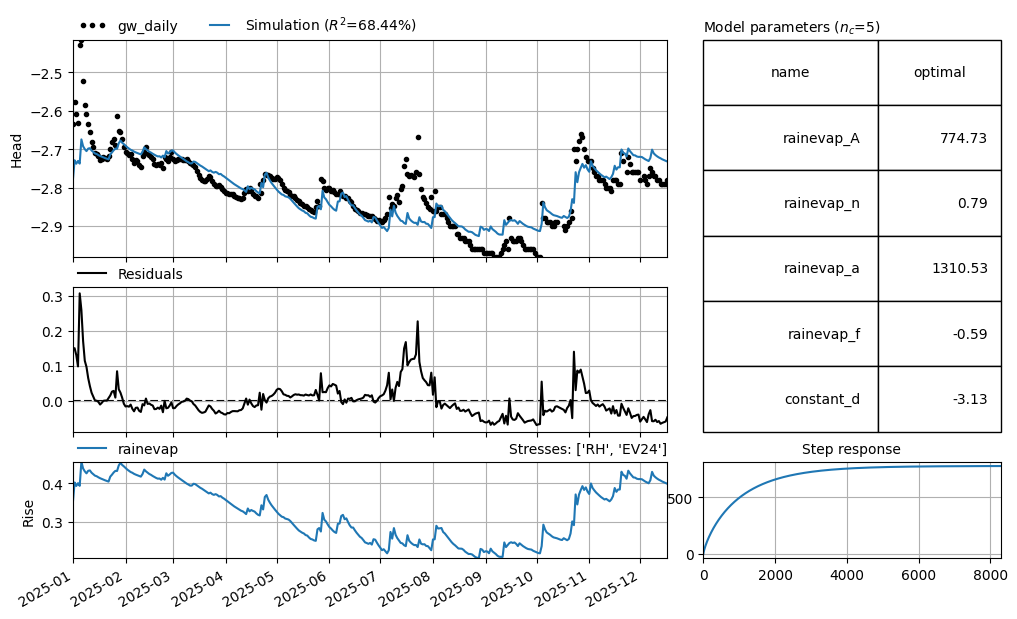

In [8]:
# Create a Pastas Model
ml = ps.Model(gw_daily, name=f"{gw.name} (primary={primary_origin})")

# Add the recharge data as explanatory variable
ts1 = ps.RechargeModel(
    precipitation["RH"].resample("D").sum(),   # dagtotaal
    evaporation["EV24"].resample("D").sum(),   # dagtotaal
    ps.Gamma(),
    name="rainevap",
    settings=("prec", "evap"),
)

# Add the stressmodel to the model and solve for period after 2015
ml.add_stressmodel(ts1)
ml.solve(tmin=START_DATE, tmax=END_DATE)
ml.plots.results(figsize=(10, 6))

Discussiepunten:
- Residuen mogelijk door kunstmatige aanvoer

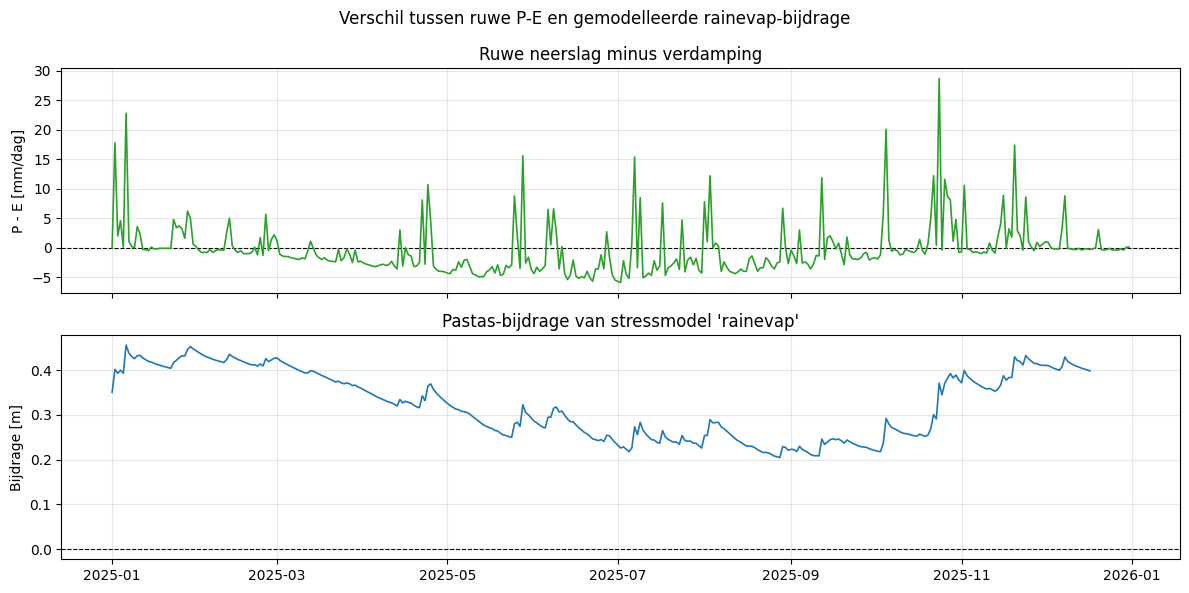

Boven: ruwe P-E in mm/dag. Onder: Pastas-bijdrage aan de grondwaterstand in m.


In [9]:
# Vergelijk ruwe P-E met de Pastas-bijdrage van het stressmodel 'rainevap'
raw_recharge = (
    precipitation["RH"].resample("D").sum()
    - evaporation["EV24"].resample("D").sum()
 ) * 1000.0
raw_recharge.name = "raw_recharge_mm_per_day"

rainevap_contribution = ml.get_contribution("rainevap")
if isinstance(rainevap_contribution, pd.DataFrame):
    if rainevap_contribution.shape[1] == 1:
        rainevap_contribution = rainevap_contribution.iloc[:, 0]
    else:
        rainevap_contribution = rainevap_contribution.sum(axis=1)
rainevap_contribution.name = "rainevap_contribution_m"

comparison = pd.concat([raw_recharge, rainevap_contribution], axis=1).loc[START_DATE:END_DATE]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].plot(
    comparison.index,
    comparison["raw_recharge_mm_per_day"],
    color="tab:green",
    linewidth=1.2,
 )
axes[0].set_ylabel("P - E [mm/dag]")
axes[0].set_title("Ruwe neerslag minus verdamping")
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].plot(
    comparison.index,
    comparison["rainevap_contribution_m"],
    color="tab:blue",
    linewidth=1.2,
 )
axes[1].set_ylabel("Bijdrage [m]")
axes[1].set_title("Pastas-bijdrage van stressmodel 'rainevap'")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Verschil tussen ruwe P-E en gemodelleerde rainevap-bijdrage")
plt.tight_layout()
plt.show()

print("Boven: ruwe P-E in mm/dag. Onder: Pastas-bijdrage aan de grondwaterstand in m.")